# Reading t-digest products: tensors and raw values

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/englacial/zagg/main?urlpath=lab/tree/notebooks/tdigest_reader_example.ipynb)

_Runs end-to-end on [Binder](https://mybinder.org/v2/gh/englacial/zagg/main?urlpath=lab/tree/notebooks/tdigest_reader_example.ipynb): it builds a small synthetic t-digest store in memory -- no cloud data, no credentials. The Binder image already provides `zagg[analysis]` (incl. matplotlib) via the repo's `.binder/` environment._

zagg writes a gridded Zarr product where each coverage chunk is a `64 x 64`
block of child cells, and each populated cell carries a **t-digest** sketch of
its observed values (e.g. ICESat-2 photon elevations). The sketch is stored as
a ragged [CSR](https://en.wikipedia.org/wiki/Sparse_matrix#Compressed_sparse_row_(CSR,_CRS_or_Yale_format))
field (issue #48).

A downstream client usually wants something denser and fixed-size. The
`zagg.readers` package (issue #79) reconstructs that from the stored digests:

- **`read_tensors`** -- a generator yielding `(tensor, morton_index)` per chunk,
  where `tensor` has shape `(64, 64, n_bins)`: each cell's digest rasterized into
  `n_bins` evenly-spaced z-bins.
- **`read_raw_values`** -- the lossless companion: when a cell's digest was built
  with no merges, its centroid means *are* the original samples, so the raw value
  vector is recovered exactly (and it raises when that is not possible).

This notebook is **self-contained**: it builds a small synthetic t-digest store
in memory, so it runs anywhere (including Binder) with no external data or
credentials. The store is built with the same public API zagg uses to write the
real product (`zagg.stats.tdigest.build_tdigest` + `zagg.csr.write_csr`), so the
read path exercised here is identical to the one a real product uses.

## 0. Requirements

The reader API (`read_tensors` / `read_raw_values`) needs only zagg's core
dependencies (numpy + zarr). The one plot below uses `matplotlib`, which ships
in zagg's `analysis` extra.

- **On Binder** nothing to do -- the repo's `.binder/` environment already
  installs `zagg[analysis]` (matplotlib included), so every cell runs as-is.
- **Standalone** (your own laptop/hub), install once with
  `pip install 'zagg[analysis]'` before running the notebook.

## 1. Build a synthetic t-digest store

We mimic two coverage chunks (parent morton ids `100` and `250`), each with a
handful of populated cells. For every populated cell we draw some samples and
sketch them with `build_tdigest`, then write all of a chunk's per-cell digests
as one CSR subgroup under `{field}/{parent_morton}` -- exactly the layout
`read_tensors` consumes.

A real product would instead point the readers at an on-disk or S3-backed Zarr
store of the same shape; nothing else about the read code changes.

In [1]:
import numpy as np
from zarr.storage import MemoryStore

from zagg.csr import write_csr
from zagg.stats.tdigest import build_tdigest

FIELD = "h_tdigest"  # the t-digest field name, e.g. elevation digests
rng = np.random.default_rng(0)


def write_chunk(store, field, parent_morton, cell_to_values, *, delta=512):
    """Write one chunk's per-cell digests as a CSR subgroup {field}/{morton}."""
    cell_ids = sorted(cell_to_values)
    digests = [build_tdigest(np.asarray(cell_to_values[c]), delta=delta) for c in cell_ids]
    write_csr(store, f"{field}/{parent_morton}", digests, cell_ids)


store = MemoryStore()

# Chunk 100: elevations clustered around ~20 m. cell_id is the cell's position
# in the chunk's row-major (64x64) children block (so 0 -> (0,0), 4095 -> (63,63)).
write_chunk(
    store,
    FIELD,
    100,
    {
        0: rng.normal(20.0, 2.0, 3_000),
        5: rng.normal(22.0, 1.5, 2_000),
        4095: rng.normal(19.0, 2.5, 1_500),
    },
)

# Chunk 250: a different elevation band, ~50 m.
write_chunk(
    store,
    FIELD,
    250,
    {
        7: rng.normal(50.0, 3.0, 2_500),
        63: rng.normal(52.0, 2.0, 2_000),
    },
)

import zarr

group = zarr.open_group(store, path=FIELD, mode="r")
print("chunk subgroups written:", sorted(int(k) for k in group.group_keys()))


chunk subgroups written: [100, 250]


Each chunk is now three CSR arrays per subgroup: `values` (the flat
concatenation of every cell's `(k_centroids, 2)` `(mean, weight)` digest),
`offsets`, and `cell_ids`. We can peek at one cell's digest to confirm.

In [2]:
from zagg.csr import iter_csr_cells, read_csr

csr = read_csr(store, f"{FIELD}/100")
cells = iter_csr_cells(csr)
print(f"chunk 100 has {len(cells)} populated cells: {[c for c, _ in cells]}")
cell_id, digest = cells[0]
print(f"\ncell {cell_id} digest shape {digest.shape} (k_centroids, [mean, weight]):")
print(digest[:5])

chunk 100 has 3 populated cells: [0, 5, 4095]

cell 0 digest shape (554, 2) (k_centroids, [mean, weight]):
[[12.201157   1.       ]
 [12.45545    1.       ]
 [13.6053095  1.       ]
 [13.770982   1.       ]
 [13.787327   1.       ]]


## 2. `read_tensors`: dense fixed-size tensors

`read_tensors` yields `(tensor, morton_index)` per chunk. For each chunk it:

1. trims each cell's tails to the `bottom`/`top` quantiles (default 5%/95%),
2. anchors a fixed `n_bins * resolution` z-window at the floor of the trimmed
   range,
3. rasterizes every cell's digest into `n_bins` per-bin counts over that window,
4. emits the `(64, 64, n_bins)` tensor plus the chunk's morton id (recovered
   from the store).

Defaults: `n_bins=128`, `resolution=0.5` m (a 64 m window), `dtype="uint32"`.

In [3]:
from zagg.readers import read_tensors

tensors = {morton: tensor for tensor, morton in read_tensors(store, FIELD)}

for morton, tensor in sorted(tensors.items()):
    nonzero_cells = int((tensor.sum(axis=2) > 0).sum())
    print(
        f"chunk morton={morton}: tensor {tensor.shape} dtype={tensor.dtype}, "
        f"{nonzero_cells} populated cells, total counts={int(tensor.sum())}"
    )

chunk morton=100: tensor (64, 64, 128) dtype=uint32, 3 populated cells, total counts=6404
chunk morton=250: tensor (64, 64, 128) dtype=uint32, 2 populated cells, total counts=4384


The morton id is the chunk's coverage cell, recovered straight from the store
(the CSR subgroup name, or a sibling `{field}/morton` coordinate array when
present). Populated cells land at their row-major position; everything else is
zero.

In [4]:
tensor = tensors[100]
# cell 5 -> (row 0, col 5); cell 4095 -> (row 63, col 63); cell 10 unpopulated.
print("cell 5   (0, 5)  count sum:", int(tensor[0, 5].sum()))
print("cell 4095 (63,63) count sum:", int(tensor[63, 63].sum()))
print("cell 10  (0,10) count sum:", int(tensor[0, 10].sum()), "(unpopulated)")

cell 5   (0, 5)  count sum: 2000
cell 4095 (63,63) count sum: 1424
cell 10  (0,10) count sum: 0 (unpopulated)


### The reconstructed histogram

Each cell's length-`n_bins` vector is a histogram reconstructed from the digest
CDF. Plotting one cell's vector against the z-bin edges shows the recovered
distribution -- here a roughly Gaussian elevation profile centred near 20 m.

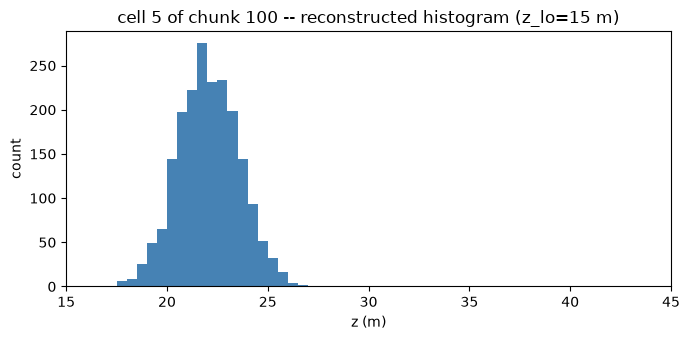

In [5]:
import matplotlib.pyplot as plt

n_bins, resolution = 128, 0.5
vec = tensor[0, 5]  # the digest histogram for cell 5 of chunk 100

# Reconstruct the window the reader used: floor of the chunk's trimmed minimum.
# We recompute the floor here only to label the x-axis; the reader sets it internally.
from zagg.readers import chunk_z_range

digests = [d for _, d in iter_csr_cells(read_csr(store, f"{FIELD}/100"))]
z_lo, n_bins_c, res_c = chunk_z_range(
    digests, n_bins=n_bins, resolution=resolution, bottom=0.05, top=0.95, fit="raise"
)
edges = z_lo + res_c * np.arange(n_bins_c + 1)
centers = 0.5 * (edges[:-1] + edges[1:])

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(centers, vec, width=res_c, align="center", color="steelblue", edgecolor="none")
ax.set_xlabel("z (m)")
ax.set_ylabel("count")
ax.set_title(f"cell 5 of chunk 100 -- reconstructed histogram (z_lo={z_lo:.0f} m)")
ax.set_xlim(z_lo, z_lo + 30)  # zoom to the populated region
plt.tight_layout()
plt.show()

### Output dtype flag

The client consumes `uint16`; `read_tensors` also offers `uint32` (the default,
safe for dense cells with many counts per bin) and `float32` (keeps fractional
reconstructed counts). The flag only changes the output cast.

In [6]:
for dtype in ("uint16", "uint32", "float32"):
    t, _ = next(read_tensors(store, FIELD, dtype=dtype))
    print(f"dtype={dtype:8s} -> tensor.dtype={t.dtype}, peak bin count={t.max()}")

dtype=uint16   -> tensor.dtype=uint16, peak bin count=295
dtype=uint32   -> tensor.dtype=uint32, peak bin count=295
dtype=float32  -> tensor.dtype=float32, peak bin count=295.212646484375


## 3. Fit policy: when the trimmed range exceeds the window

The window is fixed at `n_bins * resolution` (64 m by default). If a chunk's
trimmed `bottom`->`top` range is wider than that, the `fit` flag decides:

- `"raise"` (default) -- raise, so the client never silently loses tails;
- `"degrade_resolution"` -- double `resolution` in powers of two until it fits
  (keeps `n_bins`);
- `"collapse_bins"` -- shrink `n_bins` to the smallest power of two that fits
  (keeps `resolution`).

We build a deliberately wide chunk (elevations spanning ~400 m) to trigger it.

In [7]:
wide = MemoryStore()
write_chunk(wide, FIELD, 1, {0: rng.uniform(0.0, 400.0, 5_000)})

# Default fit="raise": the 400 m span overflows the 64 m window.
try:
    next(read_tensors(wide, FIELD, bottom=0.0, top=1.0))
except ValueError as exc:
    print("fit='raise' ->", exc)

fit='raise' -> trimmed z-range [0, 400] (span 400) exceeds the fixed window 128 bins × 0.5 = 64.0; pass fit="degrade_resolution" or fit="collapse_bins" to adapt


In [8]:
# degrade_resolution: coarsen the bins until the full span fits in 128 bins.
t, _ = next(read_tensors(wide, FIELD, bottom=0.0, top=1.0, fit="degrade_resolution"))
print("fit='degrade_resolution' -> tensor", t.shape, "dtype", t.dtype)

# collapse_bins on a *narrow* chunk: shrink n_bins to the smallest pow2 that fits.
narrow = MemoryStore()
write_chunk(narrow, FIELD, 2, {0: rng.uniform(100.0, 110.0, 4_000)})
t2, _ = next(read_tensors(narrow, FIELD, bottom=0.0, top=1.0, fit="collapse_bins"))
print("fit='collapse_bins' -> tensor", t2.shape, "(n_bins collapsed to fit ~10 m span)")

fit='degrade_resolution' -> tensor (64, 64, 128) dtype uint32
fit='collapse_bins' -> tensor (64, 64, 32) (n_bins collapsed to fit ~10 m span)


## 4. `read_raw_values`: lossless recovery

When a cell's digest was built with **no merges** -- every centroid weight is 1,
which happens whenever a cell has at most `delta` samples -- the centroid means
are exactly the original observations. `read_raw_values` yields
`(morton_index, cell_id, values)` for each such cell, with `values` the recovered
sample vector (sorted ascending, as the digest stores centroids by mean).

If any cell carries a merged centroid (weight > 1), exact recovery is impossible
and the reader raises -- the same `raise`-by-default contract as `read_tensors`.

In [9]:
from zagg.readers import read_raw_values

lossless = MemoryStore()
samples = np.array([3.0, 1.0, 2.0, 5.0, 4.0])  # 5 values, well under delta -> no merges
write_chunk(lossless, FIELD, 42, {7: samples}, delta=512)

for morton, cell_id, values in read_raw_values(lossless, FIELD):
    print(f"chunk {morton}, cell {cell_id}: recovered {values}")
    print("matches sorted input:", np.allclose(values, np.sort(samples)))

chunk 42, cell 7: recovered [1. 2. 3. 4. 5.]
matches sorted input: True


In [10]:
# A cell with many samples at a small delta forces merges -> not recoverable.
merged = MemoryStore()
write_chunk(merged, FIELD, 1, {0: rng.standard_normal(5_000)}, delta=64)
try:
    list(read_raw_values(merged, FIELD))
except ValueError as exc:
    print("merged digest ->", exc)

merged digest -> cell 0 (chunk 1) has merged centroids (weight > 1); raw values are not losslessly recoverable


## Summary

- `read_tensors(store, field, ...)` -> dense `(64, 64, n_bins)` tensors per chunk,
  with `bottom`/`top` tail-trim, a `fit` policy for wide chunks, and a `dtype`
  flag (`uint16`/`uint32`/`float32`).
- `read_raw_values(store, field)` -> exact samples per cell when the digest is
  merge-free, raising otherwise.

Both read the CSR ragged t-digest field zagg writes and recover the chunk morton
id from the store. Point them at a real on-disk or S3 Zarr product and the same
calls apply -- only the `store` argument changes.

> **Note:** this notebook uses a synthetic in-memory store so it stays
> Binder-runnable with no credentials. A companion check against a non-synthetic
> (real-product) t-digest store is tracked as a follow-up on issue #79.